## Load Data

In [2]:
import pandas as pd

df = pd.read_csv('TMDB_female_representation.csv')
df.shape
df.head()
df.info()
df.describe()
df['representation_tier'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20070 entries, 0 to 20069
Data columns (total 55 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tmdb_id                20070 non-null  int64  
 1   title                  20070 non-null  object 
 2   release_date           20070 non-null  object 
 3   release_year           20070 non-null  int64  
 4   decade                 20070 non-null  int64  
 5   overview               20070 non-null  object 
 6   popularity             20070 non-null  float64
 7   budget                 20070 non-null  int64  
 8   revenue                20070 non-null  int64  
 9   runtime                20070 non-null  int64  
 10  vote_average           20070 non-null  float64
 11  vote_count             20070 non-null  int64  
 12  original_language      20070 non-null  object 
 13  genre_names            20070 non-null  object 
 14  primary_country        20070 non-null  object 
 15  pr

representation_tier
moderate    9242
weak        6236
strong      4592
Name: count, dtype: int64

## Dataframe Finalization

In [4]:
# MODIFYING DATAFRAME FOR GENRE CLASSIFICATION! 
# I'm keeping unknowns for now (unknown gender) to preserve row count, we can filter out later 

# drop budget, revenue, runtime  
cols_to_drop = ['budget', 'revenue', 'runtime']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f'Dropped columns: {cols_to_drop}')

# Genre remapping (top 10 + remap 4 remaining genres)
# Science Fiction merged into Adventure 
# Crime merged into Thriller 
TOP_10_GENRES = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
    'Horror', 'Adventure', 'Family', 'Science Fiction', 'Crime'
]

GENRE_REMAP = {
    'Fantasy':         'Adventure',
    'Animation':       'Family',
    'Mystery':         'Thriller',
    'Documentary':     'Drama',
    # Merge smaller genres
    'Science Fiction': 'Adventure',  # sci-fi → adventure
    'Crime':           'Thriller',   # crime → thriller
}

# Final output classes after merging
FINAL_GENRES = [
    'Drama', 'Comedy', 'Action', 'Horror', 'Thriller',
    'Romance', 'Family', 'Adventure'
]

def assign_primary_genre_v5(genre_str):
    """
    Assigns primary genre using a multi-pass approach:
    Pass 1: Take first listed genre if it's in top 10 and NOT Drama or Comedy
    Pass 2a: If first genre IS Drama, check second then third genre for
             reassignment to reduce Drama dominance
    Pass 2b: If first genre IS Comedy, check second then third genre for
             reassignment to reduce Comedy dominance
    Pass 3: Scan all genres for top 10 match, then remap rare genres
    Final: Apply GENRE_REMAP to collapse into 8 final classes
    """
    if not isinstance(genre_str, str):
        return None

    genres = [g.strip() for g in genre_str.split('|')]

    # Genres we prefer to reassign Drama to if found as second/third genre
    DRAMA_REASSIGN = {
        'Romance', 'Thriller', 'Crime', 'Horror',
        'Action', 'Science Fiction', 'Adventure', 'Family'
    }

    # Genres we prefer to reassign Comedy to if found as second/third genre
    COMEDY_REASSIGN = {
        'Romance', 'Family', 'Adventure', 'Thriller',
        'Crime', 'Horror', 'Action', 'Science Fiction'
    }

    def remap(g):
        """Apply final genre merging — Science Fiction → Adventure, Crime → Thriller"""
        return GENRE_REMAP.get(g, g)

    # Pass 1: first genre is in top 10 and not Drama or Comedy 
    if genres[0] in TOP_10_GENRES and genres[0] not in ['Drama', 'Comedy']:
        return remap(genres[0])

    # Pass 2a: first genre is Drama, check second then third genre
    if genres[0] == 'Drama':
        if len(genres) > 1 and genres[1] in DRAMA_REASSIGN:
            return remap(genres[1])
        if len(genres) > 2 and genres[2] in DRAMA_REASSIGN:
            return remap(genres[2])
        return 'Drama'

    # Pass 2b: first genre is Comedy, heck second then third genre
    if genres[0] == 'Comedy':
        if len(genres) > 1 and genres[1] in COMEDY_REASSIGN:
            return remap(genres[1])
        if len(genres) > 2 and genres[2] in COMEDY_REASSIGN:
            return remap(genres[2])
        return 'Comedy'

    # Pass 3: scan all genres for top 10 match, then remap rare genres
    for genre in genres:
        if genre in TOP_10_GENRES:
            return remap(genre)
    for genre in genres:
        if genre in GENRE_REMAP:
            return remap(genre)

    return None

df['primary_genre'] = df['genre_names'].apply(assign_primary_genre_v5)

before = len(df)
df = df.dropna(subset=['primary_genre'])
after = len(df)
print(f'Dropped {before - after} rows with no genre match')

# Summary 
print(f"\n{'='*40}")
print(f'FINAL DATAFRAME: {len(df)} rows x {len(df.columns)} columns')

print(f'\nPrimary genre distribution (8 classes):')
counts = df['primary_genre'].value_counts()
for genre, count in counts.items():
    print(f'  {genre:20s}: {count:5d} ({100*count/len(df):.1f}%)')

print(f'\nRepresentation features - missing values:')
rep_features = [
    'lead_gender', 'lead_actor_age', 'pct_female_top5',
    'pct_female_cast', 'director_gender', 'director_age',
    'pct_female_writers', 'pct_female_producers'
]
for f in rep_features:
    if f in df.columns:
        missing = df[f].isna().sum()
        print(f'  {f:30s}: {missing} missing ({100*missing/len(df):.1f}%)')

print(f'\nlead_gender distribution (including unknowns):')
print(df['lead_gender'].value_counts())

Dropped columns: ['budget', 'revenue', 'runtime']
Dropped 51 rows with no genre match

FINAL DATAFRAME: 20019 rows x 53 columns

Primary genre distribution (8 classes):
  Drama               :  3955 (19.8%)
  Thriller            :  2973 (14.9%)
  Comedy              :  2826 (14.1%)
  Action              :  2678 (13.4%)
  Romance             :  2561 (12.8%)
  Horror              :  2264 (11.3%)
  Adventure           :  1590 (7.9%)
  Family              :  1172 (5.9%)

Representation features - missing values:
  lead_gender                   : 0 missing (0.0%)
  lead_actor_age                : 0 missing (0.0%)
  pct_female_top5               : 0 missing (0.0%)
  pct_female_cast               : 0 missing (0.0%)
  director_gender               : 0 missing (0.0%)
  director_age                  : 0 missing (0.0%)
  pct_female_writers            : 0 missing (0.0%)
  pct_female_producers          : 0 missing (0.0%)

lead_gender distribution (including unknowns):
lead_gender
2.0    12443
1.0  

## Genre Distribution Plot

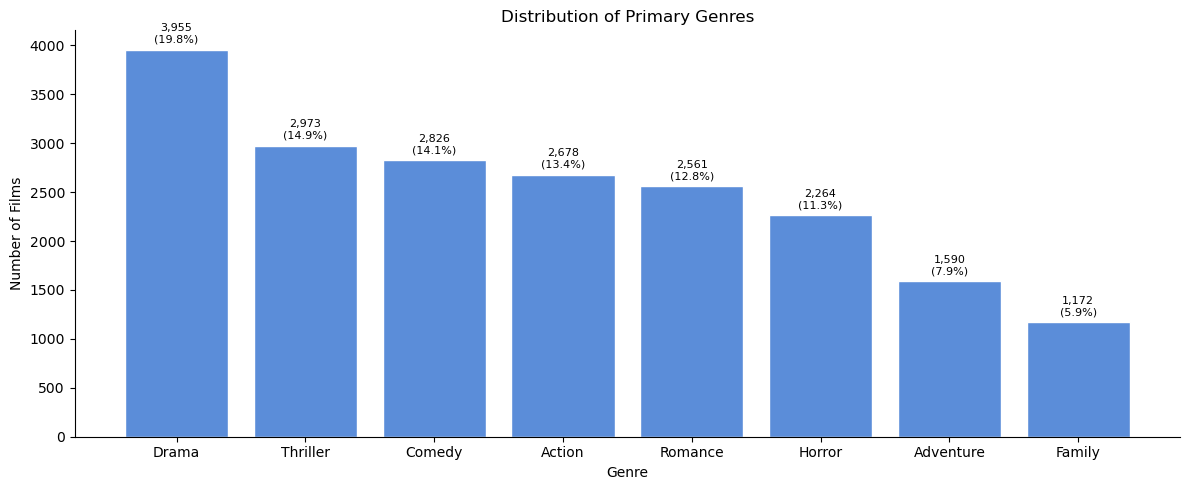

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
counts = df['primary_genre'].value_counts()
colors = ['#5b8dd9'] * len(counts)

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({100*count/len(df):.1f}%)',
            ha='center', va='bottom', fontsize=8)

ax.set_title('Distribution of Primary Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Films')
sns.despine()
plt.tight_layout()
plt.show()

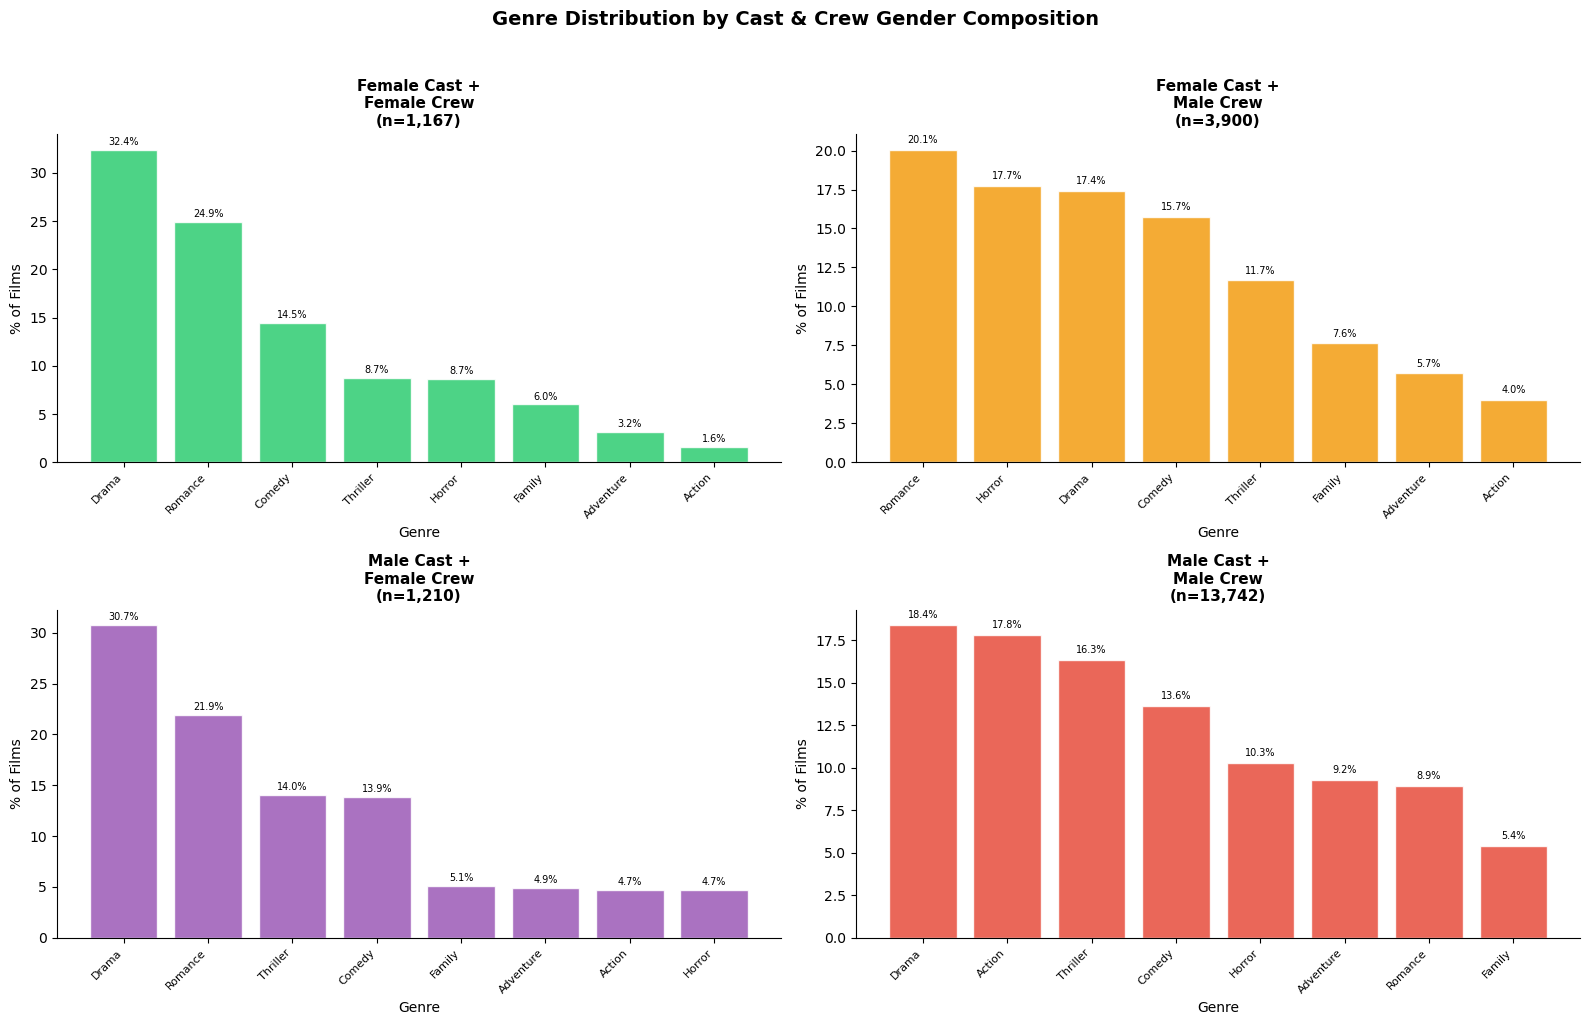

Category distribution:
  Male Cast +
Male Crew              : 13742 (68.6%)
  Female Cast +
Male Crew            :  3900 (19.5%)
  Male Cast +
Female Crew            :  1210 (6.0%)
  Female Cast +
Female Crew          :  1167 (5.8%)


In [7]:
# Plot 1: Genre Distribution by Cast/Crew Category
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recoding the director_gender from TMDb encoding (1=female, 2=male) to binary (1=female, 0=male)
df["director_female"] = df["director_gender"].map({1.0: 1, 2.0: 0})
df["pct_female_crew"] = df[["director_female", "pct_female_writers", "pct_female_producers"]].mean(axis=1)

# Threshold of 50% defines "majority" for both cast and crew
THRESHOLD = 0.5

def assign_category(row):
    female_cast = row["pct_female_cast"] >= THRESHOLD
    female_crew = row["pct_female_crew"] >= THRESHOLD
    if female_cast and female_crew:
        return "Female Cast +\nFemale Crew"
    elif female_cast and not female_crew:
        return "Female Cast +\nMale Crew"
    elif not female_cast and female_crew:
        return "Male Cast +\nFemale Crew"
    else:
        return "Male Cast +\nMale Crew"

df["cast_crew_category"] = df.apply(assign_category, axis=1)

categories = [
    "Female Cast +\nFemale Crew",
    "Female Cast +\nMale Crew",
    "Male Cast +\nFemale Crew",
    "Male Cast +\nMale Crew"
]

# Color coding: green = most female representation, red = least
colors = ["#2ecc71", "#f39c12", "#9b59b6", "#e74c3c"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, category, color in zip(axes, categories, colors):
    cat_df = df[df["cast_crew_category"] == category]
    genre_counts = cat_df["primary_genre"].value_counts()

    # Use proportions instead of raw counts so genres are comparable across
    # categories with very different sample sizes 
    genre_pct = (genre_counts / len(cat_df) * 100).sort_values(ascending=False)

    bars = ax.bar(genre_pct.index, genre_pct.values,
                  color=color, edgecolor="white", alpha=0.85)

    for bar, pct in zip(bars, genre_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=7)

    # Include sample size N in each title 
    ax.set_title(f"{category}\n(n={len(cat_df):,})", fontweight="bold", fontsize=11)
    ax.set_xlabel("Genre")
    ax.set_ylabel("% of Films")
    ax.set_xticks(range(len(genre_pct)))
    ax.set_xticklabels(genre_pct.index, rotation=45, ha="right", fontsize=8)
    sns.despine()

plt.suptitle("Genre Distribution by Cast & Crew Gender Composition",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print category breakdown to look at gender imbalance
print("Category distribution:")
cat_counts = df["cast_crew_category"].value_counts()
for cat, count in cat_counts.items():
    print(f"  {cat:35s}: {count:5d} ({100*count/len(df):.1f}%)")